In [ ]:
!pip install pandas==2.2.0 mioflow gdown

# Use MIOFlow to infer trajectories on PHATE space

Prerequisites:
- You have preprocessed your data and saved a mioflow DataFrame [notebook: 3-time-pseudotime]: 
    - rows are cells
    - columns are embeddings dimensions
    - "samples" are the discrete time labels


In this notebook, we will:
- Run MIOFlow on our PHATE space to infer trajectories

## 1. Importing MIOFlow and defining data paths

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gdown

from MIOFlow.plots import  plot_losses
from MIOFlow.eval import generate_plot_data
from MIOFlow.utils import set_seeds
set_seeds(0)


## 1. Retrieve the data and embedding normalization
First we retrieve the data.

Then, we will normalize the embeddings as a standard procedure to enable our network to learn better.

**Attention:** It is important to save the _std_ and _mean_ values. 

It is important to save the _std_ and _mean_ values because when decoding back using the `DimChanger`, we need to ensure that the outputs follow the distributions of the initial embeddings.

In [ ]:
file_id = "1zNdlGCCwiofY28cYbyv7fx3CQJPB9Omy"
url = f"https://drive.google.com/uc?id={file_id}"
output = "data.h5ad"
gdown.download(url, output, quiet=False)
adata = sc.read_h5ad("/content/data.h5ad")
adata

In [3]:
adata.obs

,n_counts,batch,day,new,sample_id,growth,log_growth,sample_labels,louvain,S_score,G2M_score,phase,emt_scores
AAACCTGAGTTCGCGC-1-4,12874.0,4,0.0,0,0,1.247017,0.318481,0,5,0.104677,0.249283,G2M,0.244868
AAACCTGCAGGACCCT-1-4,12520.0,4,0.0,0,0,0.459218,-1.122749,0,6,0.109079,-0.014701,S,6.117601
AAACCTGCATGTTGAC-1-4,10850.0,4,0.0,0,0,0.545286,-0.874916,0,5,-0.131493,-0.394984,G1,0.828480
AAACCTGGTCGAACAG-1-4,8351.0,4,0.0,0,0,1.386842,0.471803,0,5,-0.009297,-0.205679,G1,-0.143657
AAACCTGTCCGTTGCT-1-4,7429.0,4,0.0,0,0,0.067749,-3.883659,0,5,-0.117484,-0.235224,G1,-0.236617
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCCGCTGTT-1-8,6701.0,8,30.0,0,30,NaN,NaN,4,11,0.192874,0.153021,S,-0.381007
TTTGGTTTCTGCGGCA-1-8,10274.0,8,30.0,0,30,NaN,NaN,4,2,-0.122540,-0.210936,G1,-0.418274
TTTGTCACAGTCTTCC-1-8,21244.0,8,30.0,0,30,NaN,NaN,4,2,0.152778,-0.151314,S,0.455980
TTTGTCAGTACTTGAC-1-8,23182.0,8,30.0,0,30,NaN,NaN,4,2,-0.113618,-0.293476,G1,-0.614758


In [4]:
# Create a numerical bin for each unique value
adata.obs['discrete_time'], _ = pd.factorize(adata.obs['day'])

#Now lets create the data structure that mioflows works on top
mioflow_df = pd.DataFrame(adata.obsm['X_phate'], columns=[f'd{i}' for i in range(1, adata.obsm['X_phate'].shape[1]+1)])

# Add the time labels to the dataframe as a column called 'samples' (this is expected by MIOFlow)
mioflow_df['samples'] = adata.obs['discrete_time'].values
mioflow_df

,d1,d2,samples
0,0.036356,-0.005683,0
1,0.039413,0.000519,0
2,0.034858,-0.003345,0
3,0.030872,-0.004870,0
4,0.034578,-0.002362,0
...,...,...,...
16980,0.004354,0.017672,4
16981,-0.007092,0.008804,4
16982,-0.012404,0.003051,4
16983,-0.012093,0.009553,4


In [5]:
# Get embedding columns dynamically
embed_cols = [col for col in mioflow_df.columns if col.startswith('d') and col[1:].isdigit()] # Retrieve the columns that start with a d
embedding = mioflow_df[embed_cols].values
embedding

array([[ 0.03635562, -0.00568341],
       [ 0.0394135 ,  0.0005191 ],
       [ 0.03485788, -0.00334511],
       ...,
       [-0.01240443,  0.00305071],
       [-0.01209324,  0.00955291],
       [-0.0103405 ,  0.01165974]])

### Normalizing the data

In [6]:
# Normalize across all dimensions properly
mean_vals = np.mean(embedding, axis=0)
std_vals = np.std(embedding, axis=0)
std_vals = np.where(std_vals == 0, 1, std_vals)  # Prevent division by zero
normalized = (embedding - mean_vals) / std_vals
# Normalized that is going to be used to train the network
normalized

array([[ 2.16492859, -0.49814357],
       [ 2.3320683 ,  0.17329064],
       [ 2.08306395, -0.24501768],
       ...,
       [-0.50023261,  0.44734295],
       [-0.48322344,  1.15121894],
       [-0.38742085,  1.37928859]])

In [7]:
# We create the dataframe with the normalized data and the samples
df = pd.DataFrame(normalized, columns=[f'd{i+1}' for i in range(normalized.shape[1])])
df['samples'] = mioflow_df['samples']
df.head(1)

,d1,d2,samples
0,2.164929,-0.498144,0


### Let's visualize what will be our input data using PHATE

If your data looks right, and we can see a path for the trajectories to follow, we can move on to training the MIOFlow algorithm

<Axes: xlabel='d1', ylabel='d2'>

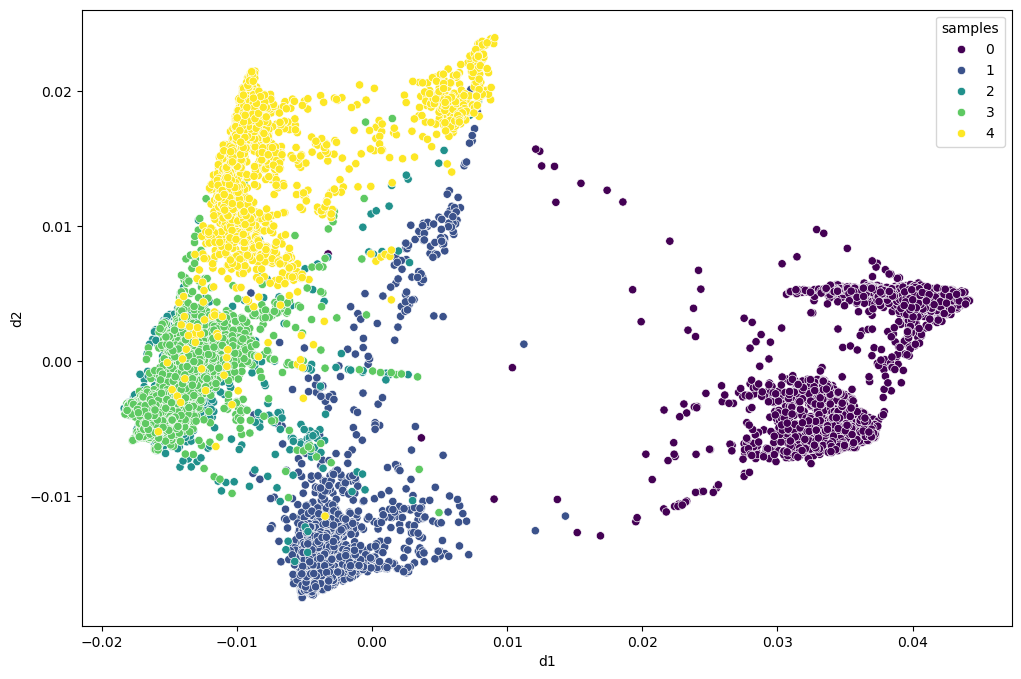

In [8]:
fig = plt.figure(figsize=(12, 8))
sns.scatterplot(data=mioflow_df, x='d1', y='d2', hue='samples', palette='viridis')

# Training the MIOFlow Model

A lot of this initial cells will be just setting up configurations to run the MIOFlow algorithm.

In [9]:
# Import torch library and verify if GPUs are available to be used.
import time
import torch
use_cuda = torch.cuda.is_available()

In [10]:
from MIOFlow.mioflow import MIOFlow

In [11]:
# =============================================================================
# MIOFlow Training Configuration
# =============================================================================

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
MODEL_CONFIG = {
    'layers': [16, 32, 16],           # Neural network architecture
    'activation': 'CELU',             # Activation function
    'scales': None,                   # SDE scales (None for default)
    'use_cuda': use_cuda,             # GPU usage
}

# =============================================================================
# TRAINING STRUCTURE CONFIGURATION
# =============================================================================
TRAINING_STRUCTURE = {
    'n_local_epochs': 40,             # Local training epochs (phase 1)
    'n_epochs': 40,                   # Global training epochs (main phase)
    'n_post_local_epochs': 0,         # Post-local training epochs (phase 3)
}

# =============================================================================
# OPTIMIZATION CONFIGURATION
# =============================================================================
OPTIMIZATION_CONFIG = {
    'criterion_type': 'ot',           # Loss criterion type ('ot' = optimal transport)
    'use_density_loss': True,         # Enable density loss (KNN-based)
    'lambda_density': 20,             # Weight for density loss
}

# =============================================================================
# DATA CONFIGURATION
# =============================================================================
DATA_CONFIG = {
    'hold_one_out': False,            # Holdout one timepoint for validation
    'sample_size': 100,               # Batch size (will be min(min_count, value))
    'reverse_schema': True,           # Use reverse trajectories for training
    'reverse_n': 2,                   # Number of reverse trajectories
}

# =============================================================================
# ADVANCED FEATURES (typically not used for single-cell data)
# =============================================================================
ADVANCED_CONFIG = {
    'autoencoder': None,              # GeodesicAutoencoder (None = disabled)
    'use_emb': False,                 # Use embeddings
    'use_gae': False,                 # Use Geodesic AutoEncoder
}

# =============================================================================
# VISUALIZATION AND OUTPUT
# =============================================================================
OUTPUT_CONFIG = {
    'exp_dir': '.',                   # Experiment directory
    'plot_every': None,                  # Plot frequency during training
    'n_points': 100,                  # Number of points for visualization
    'n_trajectories': 100,            # Number of trajectories for visualization
    'n_bins': 100,                    # Number of bins for discretization
}

# =============================================================================
# INITIALIZE MIOFLOW WITH CONFIG DICTIONARIES
# =============================================================================

# Method 1: Using dictionary unpacking (recommended)
mioflow_operator = MIOFlow(
    adata,
    input_df=mioflow_df,
    obsm_key="X_phate",
    debug_level='info',
    
    # Unpack all configurations
    **TRAINING_STRUCTURE,
    **OPTIMIZATION_CONFIG,
    **DATA_CONFIG,
    **ADVANCED_CONFIG,
    **OUTPUT_CONFIG,
    
    # Additional MIOFlow-specific parameters that aren't in your configs
    # (These will be handled by the model creation logic within MIOFlow)
    model_config=MODEL_CONFIG  # Pass the model config separately
)

# Fit the model with the configurations
mioflow = mioflow_operator.fit()


2025-08-12 17:40:37,616 - MIOFlow - INFO - MIOFlow initialized with 16985 cells and 21465 genes
2025-08-12 17:40:37,616 - MIOFlow - INFO - Output directory: .
2025-08-12 17:40:37,617 - MIOFlow - INFO - Starting MIOFlow fitting
2025-08-12 17:40:37,618 - MIOFlow - INFO - Training with structure: {'n_local_epochs': 40, 'n_epochs': 40, 'n_post_local_epochs': 0}
2025-08-12 17:40:37,618 - MIOFlow - INFO - Using CUDA: False
Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/joaofelipe/miniconda3/envs/omics-toolbox/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:658: Checkpoint directory /Users/joaofelipe/Yale/Omics Toolbox/4_Code/omics_toolbox/workshops/cancer_plasticity/mioflow/checkpoints exists and is not empty.

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | net     | Sequential | 2.9 K  | train
1 | loss_fn | MSELoss    | 0      

Training PHATE Autoencoder with 16985 cells and 2 dimensions


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

/Users/joaofelipe/Yale/Omics Toolbox/4_Code/MIOFlow/MIOFlow/train.py:265: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  batch_loss = torch.Tensor(batch_loss).float()


Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

Posttraining Epoch: 0it [00:00, ?it/s]

2025-08-12 17:42:21,136 - MIOFlow - INFO - MIOFlow fitting completed successfully


(5, 100, 2) (100, 100, 2)


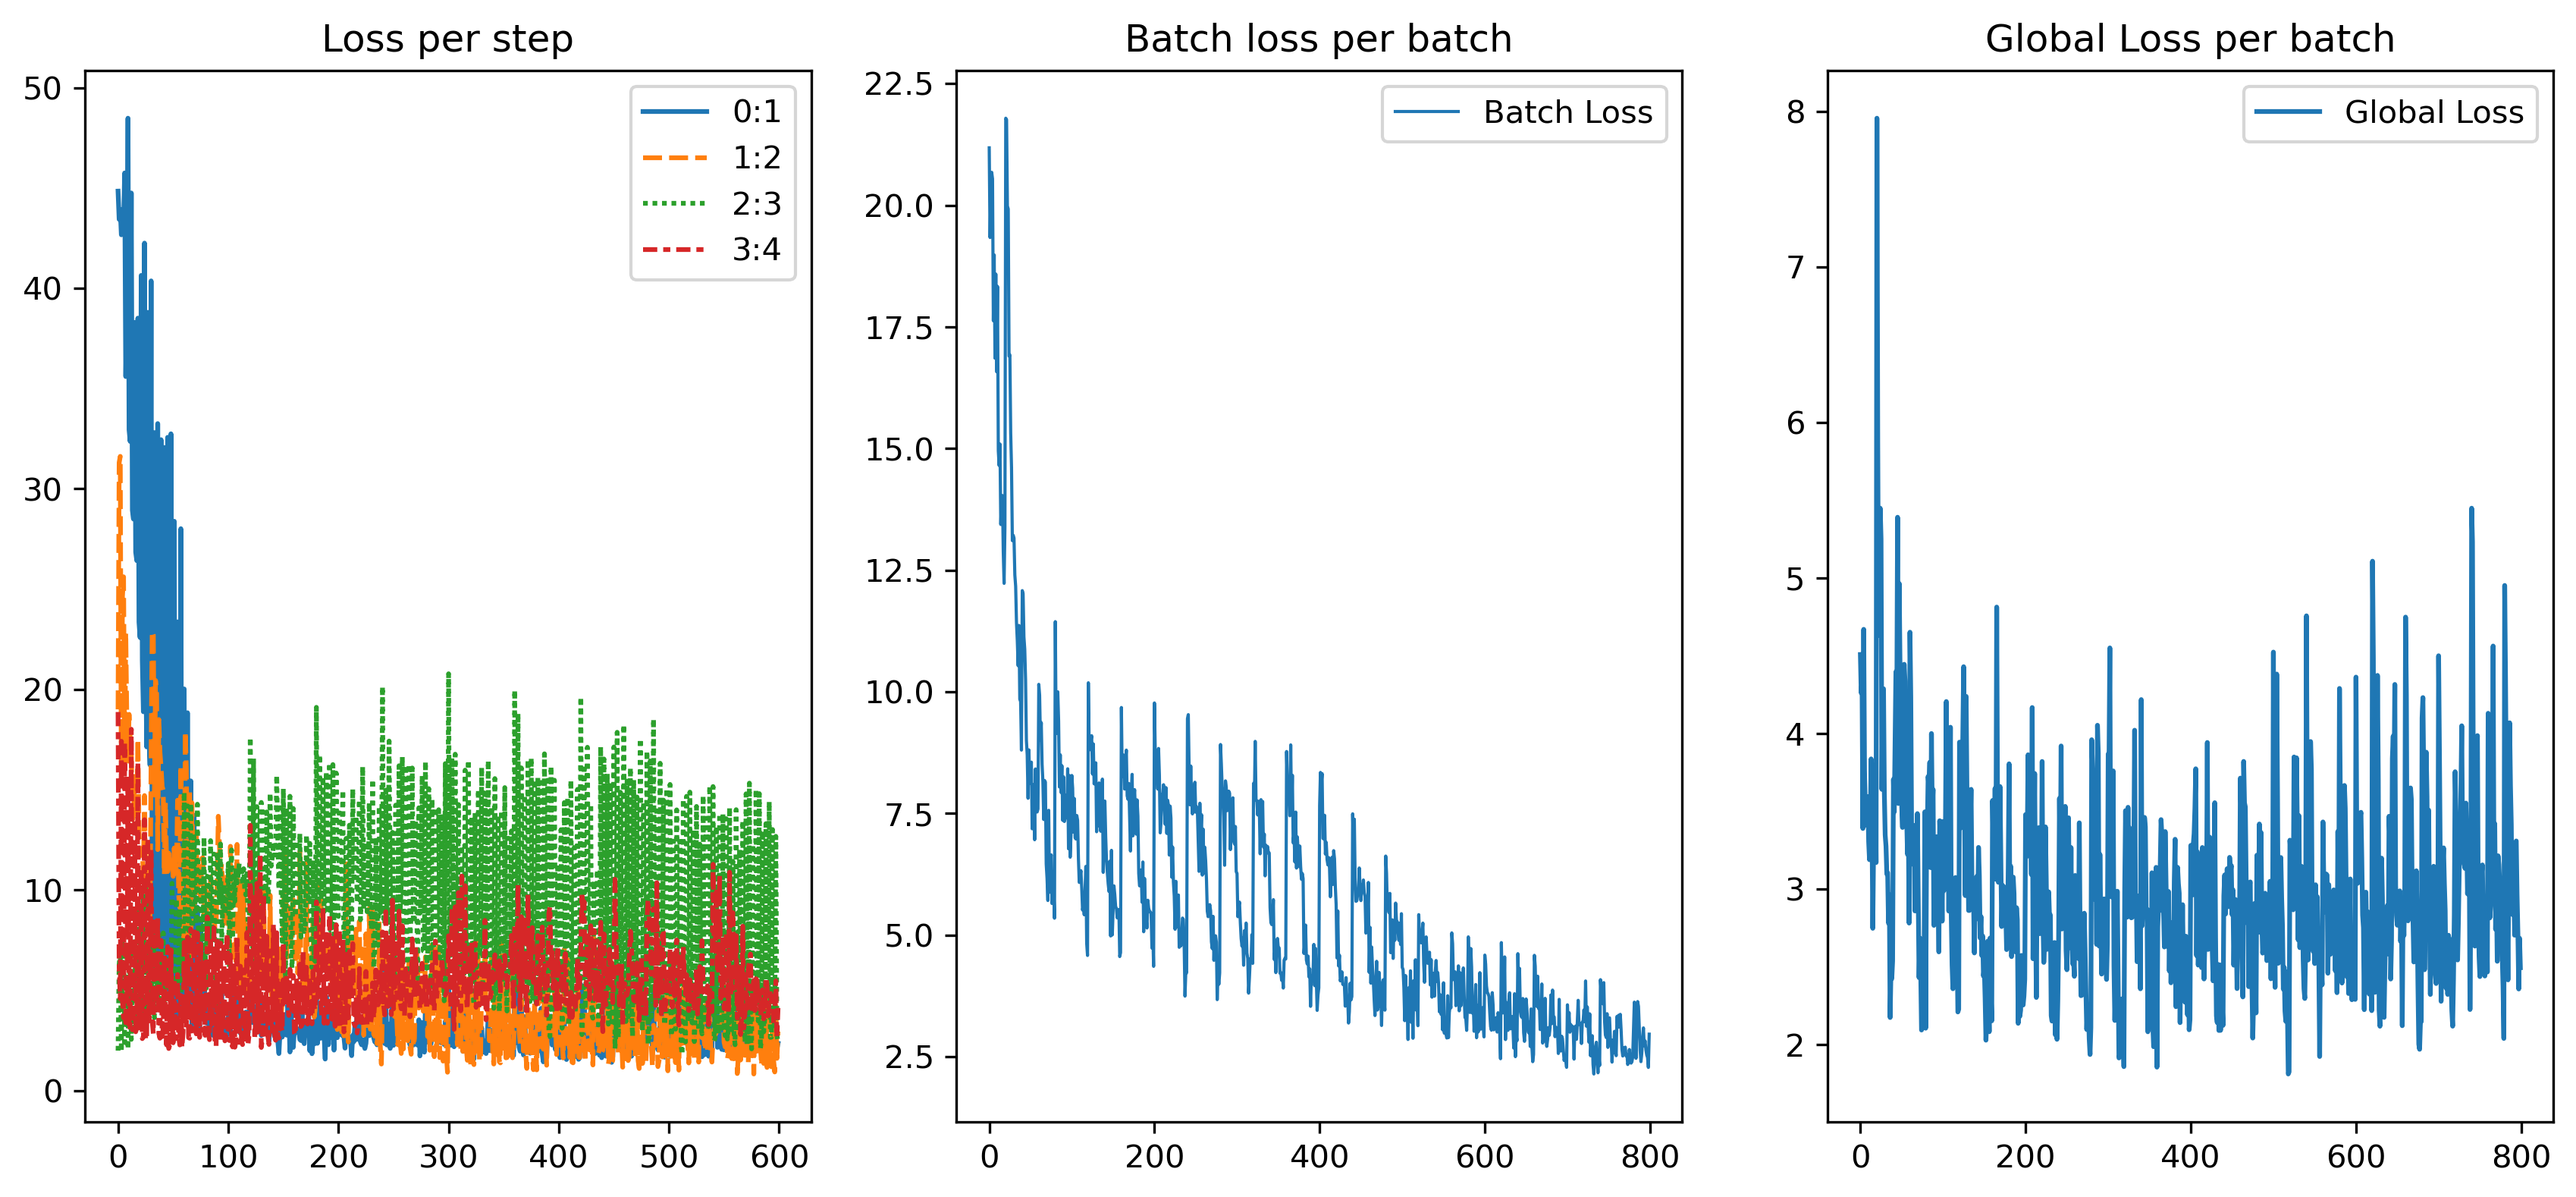

In [12]:
plot_losses(
    mioflow.local_losses, 
    mioflow.batch_losses, 
    mioflow.globe_losses, 
)

In [13]:
generated, trajectoriespts = generate_plot_data(
    mioflow.model, 
    mioflow.df, 
    n_points=100, 
    n_trajectories=100, 
    n_bins=100, 
    use_cuda=use_cuda, 
    samples_key='samples', 
    logger=None,
    autoencoder=None,
    recon=None
)

## Visualizing the MIOFlow Outputs and saving

In [14]:
trajectoriespts = mioflow.trajectories * mioflow.std_vals + mioflow.mean_vals
true_data = df[[f'd{i}' for i in range(1, len(df.columns))]] * std_vals + mean_vals

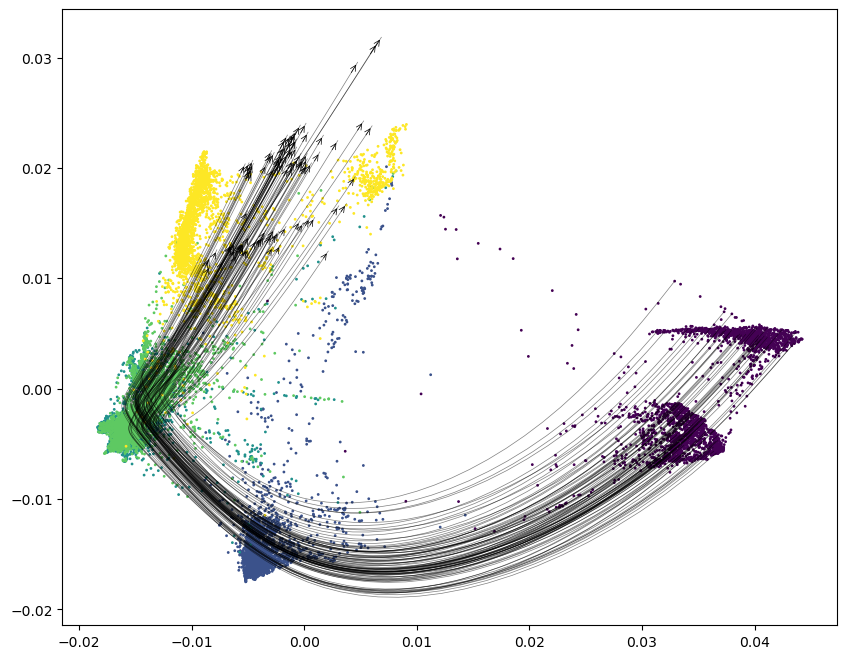

In [15]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(true_data.values[:, 0], true_data.values[:, 1], c=df['samples'].values, cmap='viridis', s=1)
for i,traj in enumerate(np.transpose(trajectoriespts, axes=(1,0,2))):
    # widths = m_traj[:,i]
    plt.plot(traj[:, 0], traj[:, 1], alpha=.5, linewidth=.5, color='Black')
    plt.annotate('', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
                 arrowprops=dict(arrowstyle='->', color='Black', lw=.5, mutation_scale=10))

# Decoding back to gene space

Now we can decode our trajectories back to gene space to understand how they behave in terms of the real gene trends

In [27]:
trajectories_gene_space = mioflow.decode_to_gene_space()

In [28]:
sc.pp.highly_variable_genes(adata, n_top_genes=25)
example_gene = adata.var_names[adata.var['highly_variable']]
example_gene_mask = adata.var_names.isin(example_gene)

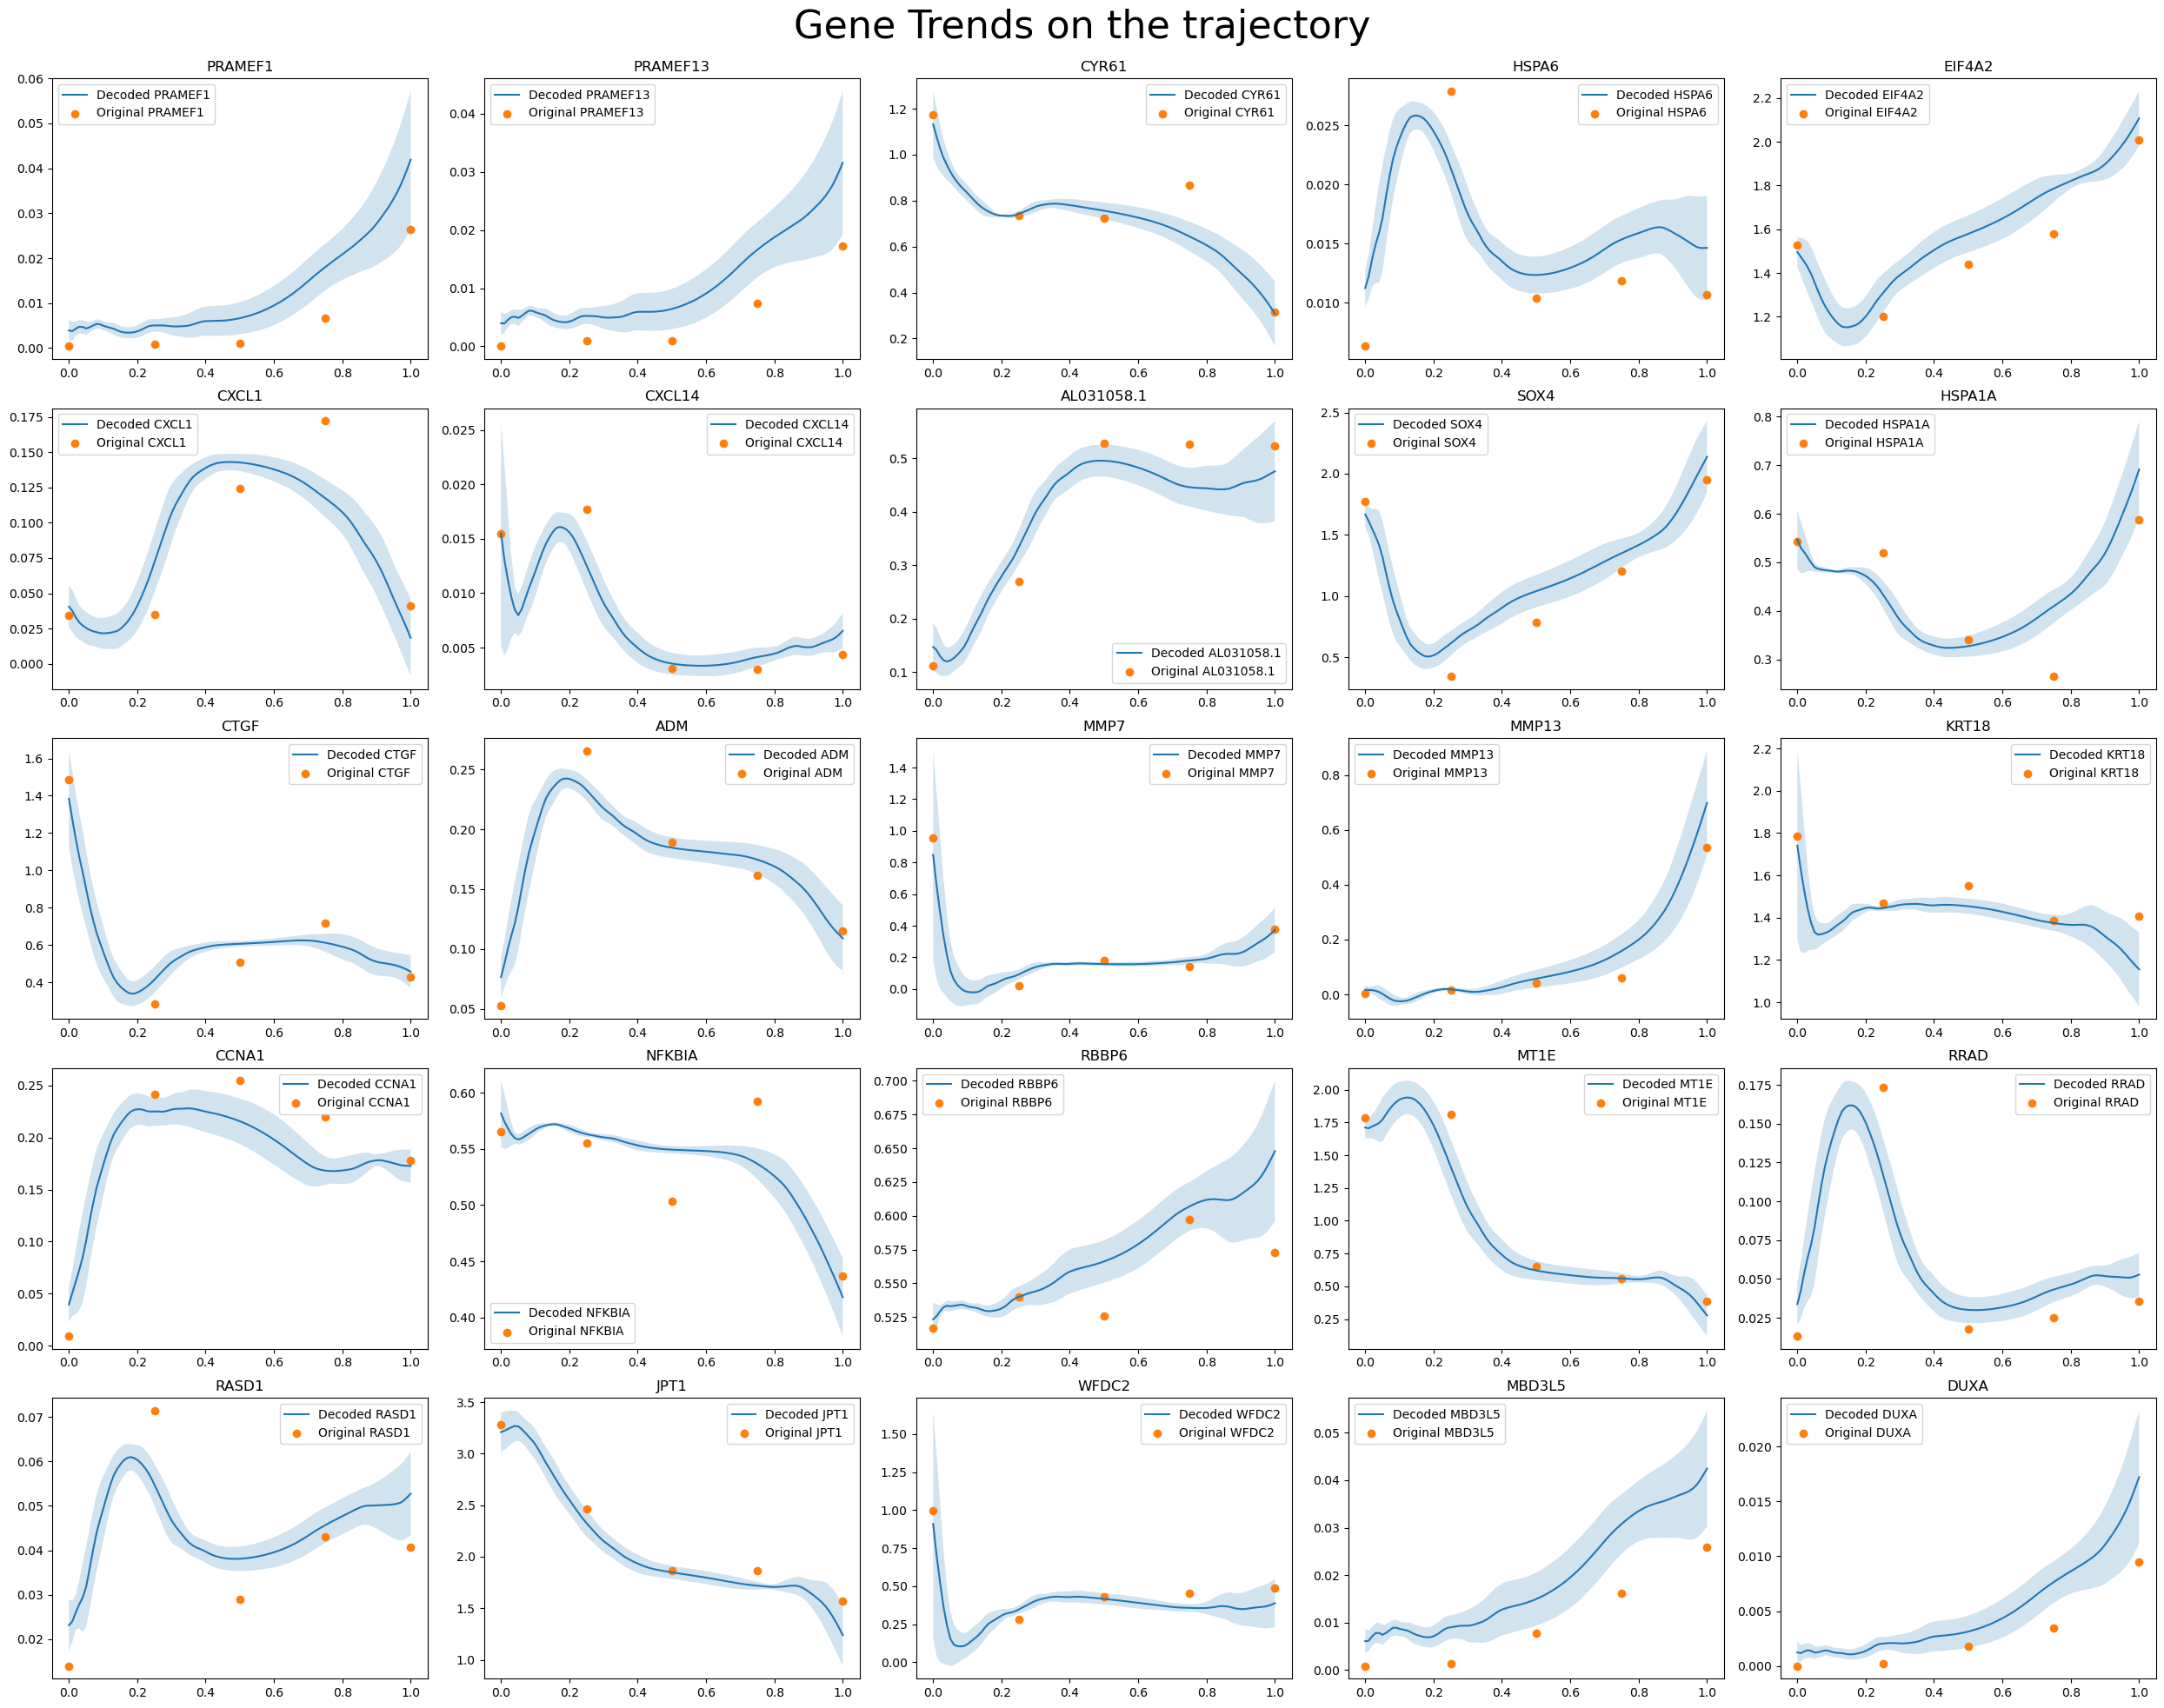

In [47]:
# Retrieving interest genes
adata_example_gene = adata[:, example_gene_mask]
decoded_example_gene = trajectories_gene_space[:, :, example_gene_mask]
decoded_example_gene_mean = decoded_example_gene.mean(axis=1)
decoded_example_gene_std = decoded_example_gene.std(axis=1)

# Setting the y axis to be through the entire trajectory
x_time = np.linspace(0, 1, traj.shape[0])
x_time_data = adata_example_gene.obs['discrete_time']
x_time_data = (x_time_data - x_time_data.min()) / (x_time_data.max() - x_time_data.min())

# Filtering the data to only show the genes of interest
data_df = pd.DataFrame(adata_example_gene.X.toarray(), columns=example_gene, index=adata_example_gene.obs_names)
data_df['x_time'] = x_time_data
data_mean = data_df.groupby('x_time').mean()
data_std = data_df.groupby('x_time').std()

# Plotting all genes in a grid
# For this we need to know how many genes we have
n_genes = decoded_example_gene_mean.shape[1]
n_rows = int(np.ceil(np.sqrt(n_genes)))
n_cols = int(np.ceil(n_genes / n_rows))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

# Finally, we plot each gene in a subplot
## The plots have the mean of the decoded gene over all trajectories in blue and the shade is the variance
for i in range(n_genes):
    ax = axes[i]
    ax.plot(x_time, decoded_example_gene_mean[:,i], label=f'Decoded {example_gene[i].split("_Cycle")[-1]}')
    ax.fill_between(x_time, decoded_example_gene_mean[:,i] - decoded_example_gene_std[:,i], decoded_example_gene_mean[:,i] + decoded_example_gene_std[:,i], alpha=0.2)
    ax.scatter(data_mean.index, data_mean[example_gene[i]], label=f'Original {example_gene[i].split("_Cycle")[-1]}')
    ax.legend()
    ax.set_title(example_gene[i])
    
# Hide empty subplots
for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.94)  # Leave space at top
plt.suptitle('Gene Trends on the trajectory', fontsize=32)  # Position suptitle in the space

plt.show()